In [26]:
from pathlib import Path
from typing import Dict
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# load data
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_DIR = BASE_DIR / "data"


def load_csv(filename: str) -> pd.DataFrame:
	file_path = DATA_DIR / filename
	return pd.read_csv(file_path)


def load_all_dataframes() -> Dict[str, pd.DataFrame]:
	return {
		"faculty_ratings": load_csv("umsi-faculty-ratings.csv"),
		"rating_posts": load_csv("umsi-rating-posts.csv"),
	}


dataframes = load_all_dataframes()
faculty_ratings = dataframes["faculty_ratings"]
rating_posts = dataframes["rating_posts"]

# Keep post id, and map faculty_id to id so merge can be on "id"
rating_posts_for_merge = rating_posts.rename(columns={"id": "post_id", "faculty_id": "id"})

merged_df = rating_posts_for_merge.merge(
	faculty_ratings,
	on="id",
	how="left",
)

True


In [25]:
pd.set_option("display.max_columns", None)
display(merged_df.head(1))

,post_id,id,text,score,date,course,tough_grader_x,get_ready_to_read_x,participation_matters_x,extra_credit_x,group_projects_x,amazing_lectures_x,clear_grading_criteria_x,gives_good_feedback_x,inspirational_x,lots_of_homework_x,hilarious_x,beware_of_pop_quizzes_x,so_many_papers_x,caring_x,respected_x,lecture_heavy_x,test_heavy_x,graded_by_few_things_x,accessible_outside_class_x,online_savvy_x,name,role,rating_url,num_ratings,overall_rating,would_take_again,level_of_difficulty,tough_grader_y,get_ready_to_read_y,participation_matters_y,extra_credit_y,group_projects_y,amazing_lectures_y,clear_grading_criteria_y,gives_good_feedback_y,inspirational_y,lots_of_homework_y,hilarious_y,beware_of_pop_quizzes_y,so_many_papers_y,caring_y,respected_y,lecture_heavy_y,test_heavy_y,graded_by_few_things_y,accessible_outside_class_y,online_savvy_y
0,42093194,101,I found Katie to be extremely passive-aggressi...,2,2025-12-08,SI110,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Katie LaPlant,Lecturer I,https://www.ratemyprofessors.com/professor/308...,7.0,1.3,0.0,4.1,1,1,1,1,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0


# Problem formulation

Students struggle to choose the best professors. Universities lack scalable ways to evaluate teaching quality. Our system uses student feedback data to provide “objective” insights into professor performance.

**We will label professors good or bad only based on the ratings from rate my professor to direct class enrollement and professor reputation.**

### Target:

- Professors (directly impacted by biased reports)
- Students (indirectly manipulated by biased reports)

### Goals

- Manipulate course demand and enrollement
- Influence professor reputation

# Data Collection

# Data Analysis

Top 5 Professors by Average Score:
name
Mustafa Naseem    5.0
Elle O'Brien      5.0
Barry Fishman     5.0
Ben Green         5.0
John Thompson     5.0
Name: score, dtype: float64

Bottom 5 Professors by Average Score:
name
Gabriela Marcu       1.600000
Katie LaPlant        1.285714
Stephanie Brenton    1.000000
Cory Knobel          1.000000
Abigail Jacobs       1.000000
Name: score, dtype: float64


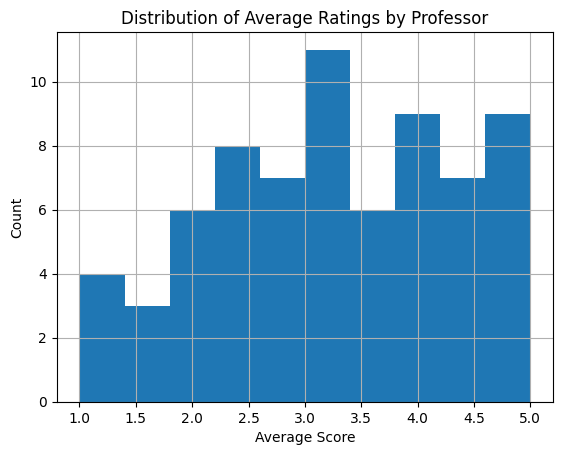

In [24]:
import matplotlib.pyplot as plt

# Average rating per professor
prof_avg = merged_df.groupby("name")["score"].mean().sort_values(ascending=False)
print("Top 5 Professors by Average Score:")
print(prof_avg.head())
print("\nBottom 5 Professors by Average Score:")
print(prof_avg.tail())

# Distribution of average scores across professors
prof_avg.hist()
plt.title("Distribution of Average Ratings by Professor")
plt.xlabel("Average Score")
plt.ylabel("Count")
plt.show()

In [33]:
from textblob import TextBlob

def get_sentiment(text):
    if pd.isna(text):
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

merged_df["sentiment"] = merged_df["text"].apply(get_sentiment)

# Check relationship
print(merged_df[["score", "sentiment"]].corr(numeric_only=True))
display(merged_df[["text", "score", "sentiment"]].head())

              score  sentiment
score      1.000000   0.607944
sentiment  0.607944   1.000000


,text,score,sentiment
0,I found Katie to be extremely passive-aggressi...,2,-0.08125
1,She tends to be very passive aggressive during...,1,0.20000
2,The professor is awful. Escape from her if you...,1,-0.18750
3,She is very rude to students and the assignmen...,1,-0.21800
4,Prof has a lot of unrealistic expectations and...,2,0.03750


Future ideas-- Talk about building a model? 
Use the sentiment analysis and asiign good/bad based on a threshold